In [49]:
# Imports
from scipy.io import arff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.inspection import permutation_importance
from sklearn.model_selection import KFold



In [3]:
# Load the .arff file
path = '../data/raw/phpn1jVwe.arff' # Update this to the path of your .arff file
data, meta = arff.loadarff(path)

In [4]:
# Convert to DataFrame
df = pd.DataFrame(data)

In [5]:
df['class'] = df['class'].str.decode('utf-8')

In [6]:
df.head()

,attr1,attr2,attr3,attr4,attr5,attr6,class
0,0.230020,5.072578,-0.276061,0.832444,-0.377866,0.480322,-1
1,0.155491,-0.169390,0.670652,-0.859553,-0.377866,-0.945723,-1
2,-0.784415,-0.443654,5.674705,-0.859553,-0.377866,-0.945723,-1
3,0.546088,0.131415,-0.456387,-0.859553,-0.377866,-0.945723,-1
4,-0.102987,-0.394994,-0.140816,0.979703,-0.377866,1.013566,-1


In [7]:
df['class'] = df['class'].map({'-1': 0, '1': 1})
df.head()

,attr1,attr2,attr3,attr4,attr5,attr6,class
0,0.230020,5.072578,-0.276061,0.832444,-0.377866,0.480322,0
1,0.155491,-0.169390,0.670652,-0.859553,-0.377866,-0.945723,0
2,-0.784415,-0.443654,5.674705,-0.859553,-0.377866,-0.945723,0
3,0.546088,0.131415,-0.456387,-0.859553,-0.377866,-0.945723,0
4,-0.102987,-0.394994,-0.140816,0.979703,-0.377866,1.013566,0


## PART A - Feature Distribution

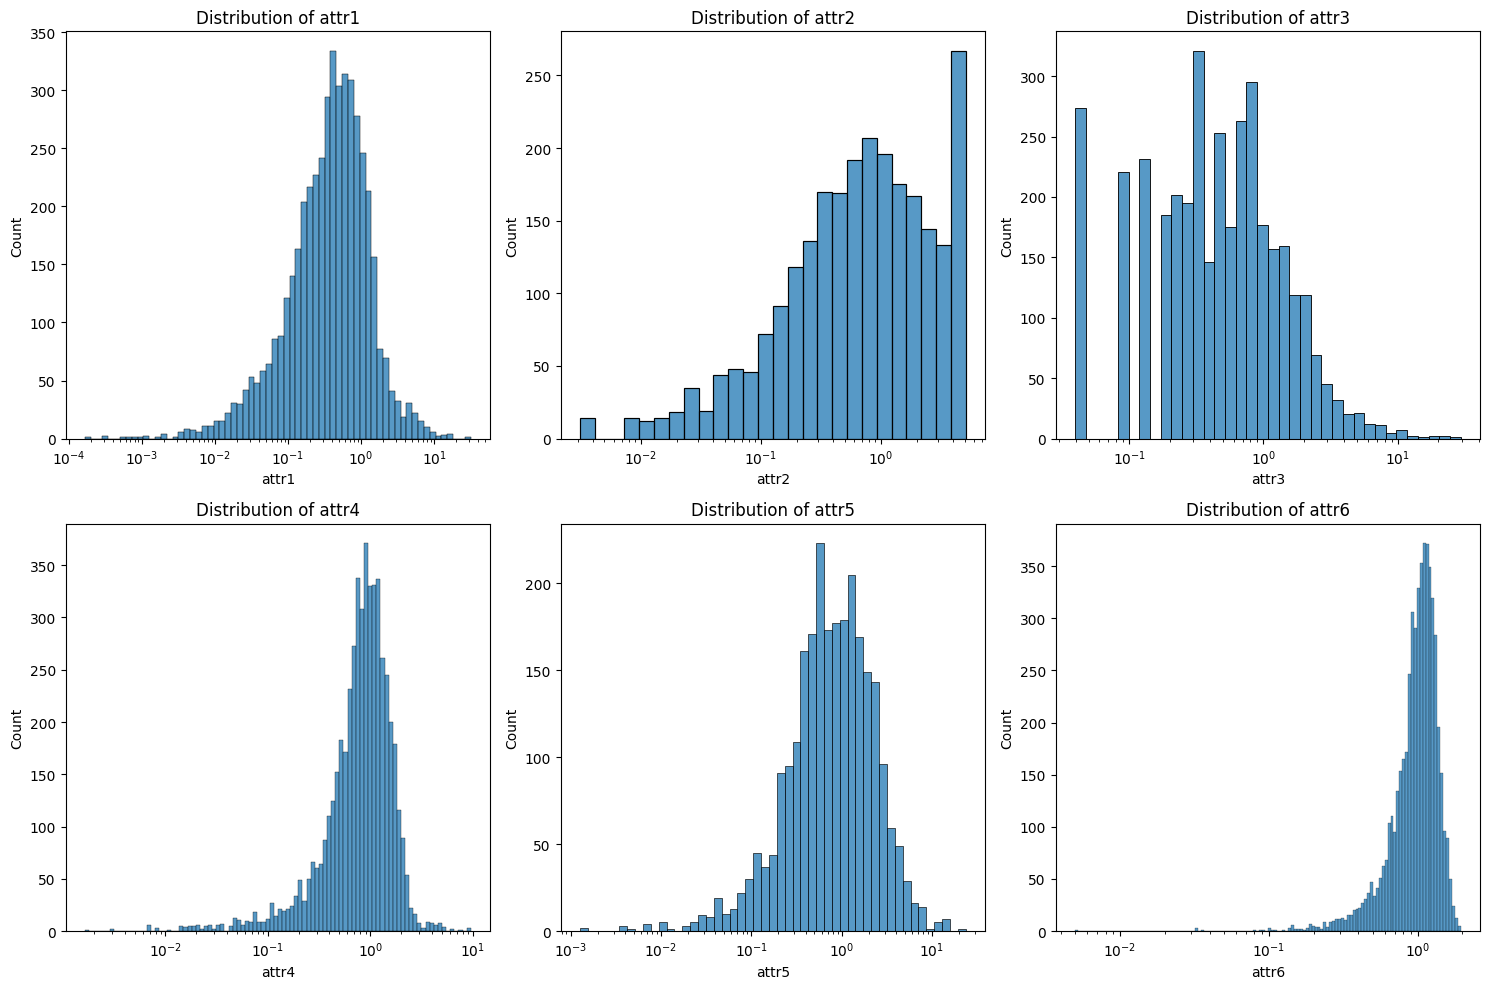

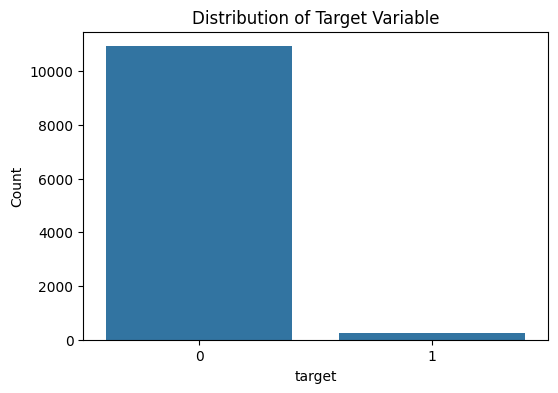

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

In [8]:
# Visualize the univariate distribution of each continuous feature, and the distribution of the target variable

# Set up the figure
plt.figure(figsize=(15, 10))
# List of continuous features
continuous_features = ['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6']
# Plot histograms for continuous features (log scale for x-axis)
for i, feature in enumerate(continuous_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[feature], kde=False, log_scale=(True, False))
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()
# Plot the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df)
plt.title('Distribution of Target Variable')
plt.xlabel('target')
plt.ylabel('Count')
plt.show()
# Visualize the bivariate relationships between the continuous features and the target variable
# Set up the figure
plt.figure(figsize=(15, 10))

## PART B - Pre-Processing

In [9]:
#add random state to ensure reproducibility
np.random.seed(42)

# Split the data into training and testing sets
X = df.drop('class', axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training set size: {X_train.shape[0]}')
print(f'Testing set size: {X_test.shape[0]}')

Training set size: 8946
Testing set size: 2237


In [10]:
# check the data type of x_train
print(X_train.dtypes)

attr1    float64
attr2    float64
attr3    float64
attr4    float64
attr5    float64
attr6    float64
dtype: object


In [23]:
# separate numeric and categorical columns and create preprocessing pipelines for each
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_features = X_train.select_dtypes(include=["object"]).columns
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [24]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [25]:
# add a random seed to ensure reproducibility

np.random.seed(42)

# define a stratified CV fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# create a pipeline that combines the preprocessor and a classifier. Use SMOTE to handle class imbalance.
pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# NOTE: moved smote, random undersampler from this pipeline to be used in a later step   - Anna

# ("smote", SMOTE(random_state=42)),
#     ('random_under_sampler', RandomUnderSampler(random_state=42)),

In [ ]:
# evaluate the model using cross-validation
# use f1 to emphasize false negatives and false positives
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='f1')
print(f'Cross-validation scores: {cv_scores}')
print(f'Mean cross-validation score: {cv_scores.mean()}')

Cross-validation scores: [0.5625     0.67605634 0.65625    0.61538462 0.66666667]
Mean cross-validation score: 0.6353715240158901


In [27]:
# try evaluation again using cross-validation and balanced accuracy
cv_balanced_scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='balanced_accuracy')
print(f'Cross-validation balanced accuracy scores: {cv_balanced_scores}')
print(f'Mean cross-validation balanced accuracy score: {cv_balanced_scores.mean()}')

Cross-validation balanced accuracy scores: [0.71314155 0.78428326 0.7497138  0.73723662 0.76133235]
Mean cross-validation balanced accuracy score: 0.7491415162180607


## PART C - Hyperparameter Tuning

In [28]:
# define the parameter grid
param_grid = [
#     {
#     'classifier': [DecisionTreeClassifier(random_state=0, class_weight='balanced')],
#     'classifier__max_depth': [2, 3, 4],
#     'classifier__min_samples_leaf': [1, 5, 10]
# },
{
    'classifier': [RandomForestClassifier(random_state=0, class_weight='balanced', n_jobs=-1)],
    'classifier__n_estimators': [300, 500, 1000],
    'classifier__max_depth': [None, 5, 10],
    # 'classifier__min_samples_leaf': [1, 5]
},
#    {
#     'classifier': [LogisticRegression(
#         random_state=0,
#         max_iter=1000,
#         class_weight='balanced',
#         solver='liblinear'
#     )],
#     'classifier__C': [0.01, 0.1, 1, 10]
# }

]

# NOTE: simplified parameter grid to make model comparison easier  - Anna

In [30]:
# Apply grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=skf, scoring='f1', n_jobs=-1, error_score='raise')
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'classifier': [RandomForestC...andom_state=0)], 'classifier__max_depth': [None, 5, ...], 'classifier__n_estimators': [300, 500, ...]}]"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [31]:
np.random.seed(42)
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Best Parameters:", best_params)
print("Best F1 Score:", best_score)

Best Parameters: {'classifier': RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=0), 'classifier__max_depth': 10, 'classifier__n_estimators': 300}
Best F1 Score: 0.6577756629335576


#### Best max_depth: 10
#### Best n_estimators: 300
#### Best F1 score: 65.78%

In [32]:
y_pred = grid_search.best_estimator_.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[2173   14]
 [  16   34]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2187
           1       0.71      0.68      0.69        50

    accuracy                           0.99      2237
   macro avg       0.85      0.84      0.84      2237
weighted avg       0.99      0.99      0.99      2237



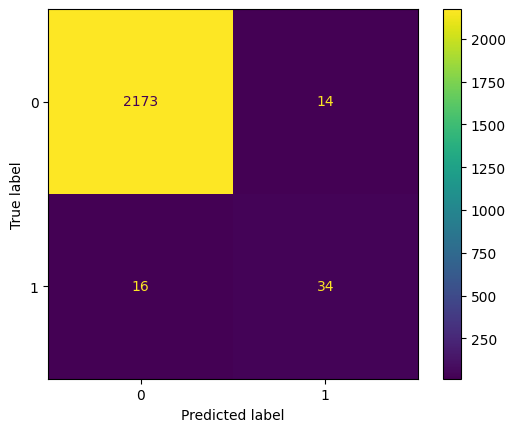

In [33]:
# plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [20]:
best = grid_search.best_estimator_
best

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
# Compare best parameters with other parameters from grid search
results = pd.DataFrame(grid_search.cv_results_)
results = results.sort_values(by='mean_test_score', ascending=False)
results.head(6)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier,param_classifier__max_depth,param_classifier__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
6,2.232326,0.720901,1.295179,0.276600,RandomForestClassifier(class_weight='balanced'...,10,300,{'classifier': RandomForestClassifier(class_we...,0.640000,0.717949,0.650000,0.649351,0.631579,0.657776,0.030837,1
7,4.360506,0.578592,0.473443,0.196504,RandomForestClassifier(class_weight='balanced'...,10,500,{'classifier': RandomForestClassifier(class_we...,0.640000,0.717949,0.634146,0.641026,0.631579,0.652940,0.032696,2
8,5.606279,0.368326,0.380652,0.098659,RandomForestClassifier(class_weight='balanced'...,10,1000,{'classifier': RandomForestClassifier(class_we...,0.640000,0.717949,0.617284,0.641026,0.613333,0.645918,0.037760,3
2,6.874302,0.226117,1.020115,0.366967,RandomForestClassifier(class_weight='balanced'...,None,1000,{'classifier': RandomForestClassifier(class_we...,0.548387,0.666667,0.557377,0.606061,0.557377,0.587174,0.044623,4
1,3.269655,0.526260,0.626756,0.278803,RandomForestClassifier(class_weight='balanced'...,None,500,{'classifier': RandomForestClassifier(class_we...,0.516129,0.666667,0.557377,0.626866,0.557377,0.584883,0.054206,5
0,1.700847,0.448840,1.315855,0.284807,RandomForestClassifier(class_weight='balanced'...,None,300,{'classifier': RandomForestClassifier(class_we...,0.539683,0.656716,0.557377,0.606061,0.548387,0.581645,0.044018,6


#### Mean Test Scores - Stratified K-Fold
| | 300 | 500 | 1000 |
|:-------:|:-------:|:-------:|:-------:|
| 10 | 65.78% | 65.29% | 64.59% |
| None | 58.17% | 58.45% | 58.72% |

There is very little difference between the n_estimator accuracy scores. However, there is a significant difference between max_depth 10 and no max_depth, with max_depth 10 being 6-7% more accurate.

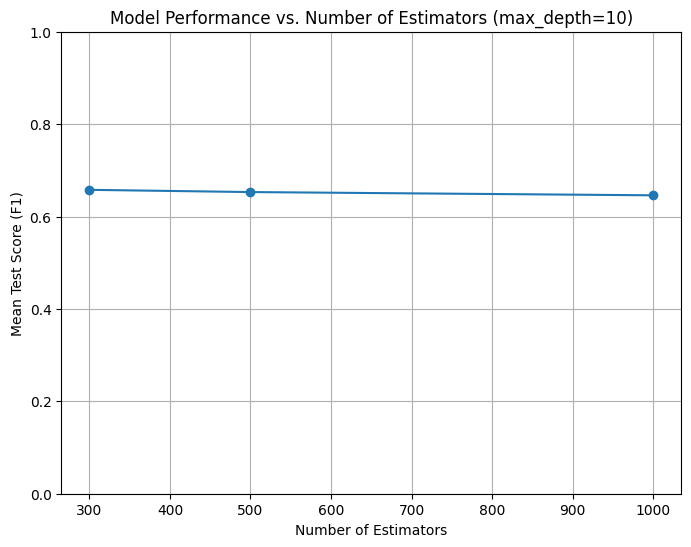

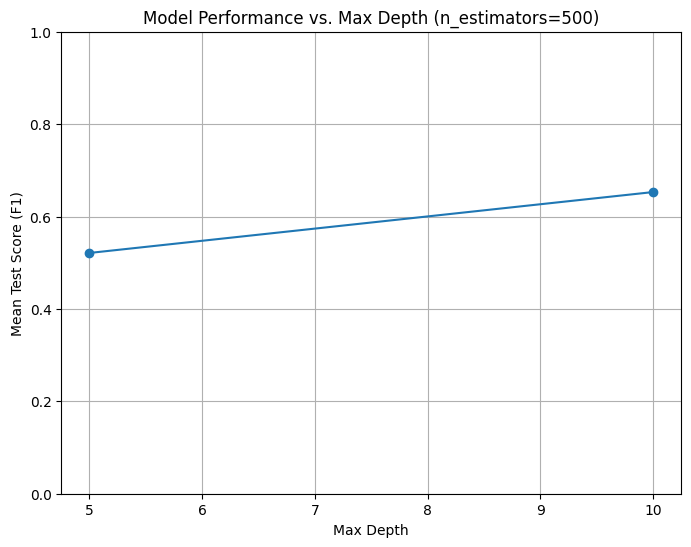

In [ ]:
# Visualize performance as a function of n_estimators where max_depth=10
subset = results[results['param_classifier__max_depth'] == 10]
plt.figure(figsize=(8, 6))
plt.plot(subset['param_classifier__n_estimators'], subset['mean_test_score'], marker='o')
plt.title('Model Performance vs. Number of Estimators (max_depth=10)')
plt.xlabel('Number of Estimators')
plt.ylabel('Mean Test Score (F1)')
plt.ylim(0, 1)  # Set y-axis limits for easier comparison
plt.grid(True)
plt.show()

# Visualize peformance as a function of max_depth where n_estimators=500
subset = results[results['param_classifier__n_estimators'] == 500].copy()

# drop rows with missing max_depth, convert to int and sort so the line connects correctly
subset = subset.dropna(subset=['param_classifier__max_depth'])
subset['param_classifier__max_depth'] = subset['param_classifier__max_depth'].astype(int)
subset = subset.sort_values('param_classifier__max_depth')

plt.figure(figsize=(8, 6))
plt.plot(subset['param_classifier__max_depth'], subset['mean_test_score'], marker='o', linestyle='-')
plt.title('Model Performance vs. Max Depth (n_estimators=500)')
plt.xlabel('Max Depth')
plt.ylabel('Mean Test Score (F1)')
plt.ylim(0, 1)  # Set y-axis limits for easier comparison
plt.grid(True)
plt.show()

These plots show that the max_depth parameter appears to have greater impact on accuracy than number of estimators.

## PART D - Switch Cross-Validation Strategy

In [50]:
# Switch cv strategy from stratified k-fold to k-fold with shuffling
cv = KFold(n_splits=5, shuffle=True, random_state=538)

In [51]:
# Do another grid search with the new cv strategy
grid_search_kf = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=cv, 
    scoring='f1'
)

In [52]:
# Fit the new grid search to the data
grid_search_kf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'classifier': [RandomForestC...andom_state=0)], 'classifier__max_depth': [None, 5, ...], 'classifier__n_estimators': [300, 500, ...]}]"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [53]:
# Find the best parameters and best score from the new grid search
best_params_kf = grid_search_kf.best_params_
best_score_kf = grid_search_kf.best_score_
print("Best Parameters with KFold:", best_params_kf)
print("Best F1 Score with KFold:", best_score_kf)

Best Parameters with KFold: {'classifier': RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=0), 'classifier__max_depth': 10, 'classifier__n_estimators': 300}
Best F1 Score with KFold: 0.632334419981837


#### Best max_depth: 10
#### Best n_estimators: 300
#### Best F1 score: 65.23%

In [54]:
# Compare results from stratified k-fold and k-fold
print("Best Parameters with StratifiedKFold:", best_params)
print("Best F1 Score with StratifiedKFold:", best_score)
print("Best Parameters with KFold:", best_params_kf)
print("Best F1 Score with KFold:", best_score_kf)

Best Parameters with StratifiedKFold: {'classifier': RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=0), 'classifier__max_depth': 10, 'classifier__n_estimators': 300}
Best F1 Score with StratifiedKFold: 0.6577756629335576
Best Parameters with KFold: {'classifier': RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=0), 'classifier__max_depth': 10, 'classifier__n_estimators': 300}
Best F1 Score with KFold: 0.632334419981837


The two strategies gave us the same best parameters. There was a slight decrease in the F1 score with the regular k-fold.

In [55]:
# Compare the best parameters from k-fold with the other paramters from that grid search
results_kf = pd.DataFrame(grid_search_kf.cv_results_)
results_kf = results_kf.sort_values(by='mean_test_score', ascending=False)
results_kf.head(6)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier,param_classifier__max_depth,param_classifier__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
6,0.737923,0.027041,0.149175,0.107925,RandomForestClassifier(class_weight='balanced'...,10,300,{'classifier': RandomForestClassifier(class_we...,0.623656,0.666667,0.633333,0.582278,0.655738,0.632334,0.029354,1
7,1.173764,0.028814,0.143475,0.015450,RandomForestClassifier(class_weight='balanced'...,10,500,{'classifier': RandomForestClassifier(class_we...,0.602151,0.675000,0.612903,0.564103,0.655738,0.621979,0.039436,2
8,2.319295,0.048070,0.265195,0.021051,RandomForestClassifier(class_weight='balanced'...,10,1000,{'classifier': RandomForestClassifier(class_we...,0.602151,0.658228,0.622951,0.526316,0.645161,0.610961,0.046454,3
0,0.810013,0.066155,0.099506,0.013585,RandomForestClassifier(class_weight='balanced'...,None,300,{'classifier': RandomForestClassifier(class_we...,0.602740,0.529412,0.629630,0.571429,0.588235,0.584289,0.033433,4
2,2.426083,0.029630,0.294078,0.045521,RandomForestClassifier(class_weight='balanced'...,None,1000,{'classifier': RandomForestClassifier(class_we...,0.563380,0.529412,0.641509,0.542857,0.641509,0.583734,0.048399,5
1,1.207953,0.041887,0.148875,0.024886,RandomForestClassifier(class_weight='balanced'...,None,500,{'classifier': RandomForestClassifier(class_we...,0.583333,0.529412,0.641509,0.542857,0.588235,0.577069,0.039391,6


#### Mean Test Scores - Regular K-Fold
| | 300 | 500 | 1000 |
|:-------:|:-------:|:-------:|:-------:|
| 10 | 63.23% | 62.19% | 61.1% |
| None | 58.43% | 57.71% | 58.37% |

Again, there is very little difference between the n_estimator accuracy scores. Max_depth none is significantly less accurate than max_depth 10 once again.

All accuracy scores are very similar to the accuracy scores in the stratified k-fold, though there may be an ever-so-slight decrease in accuracy using this method (<3% difference).

In [56]:
# Try again with a different random seed for the k-fold CV
cv = KFold(n_splits=5, shuffle=True, random_state=123)

In [57]:
# Do another grid search with the new cv strategy
grid_search_kf = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=cv, 
    scoring='f1'
)

In [58]:
# Fit the new grid search to the data
grid_search_kf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'classifier': [RandomForestC...andom_state=0)], 'classifier__max_depth': [None, 5, ...], 'classifier__n_estimators': [300, 500, ...]}]"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [59]:
# Find the best parameters and best score from the new grid search
best_params_kf = grid_search_kf.best_params_
best_score_kf = grid_search_kf.best_score_
print("Best Parameters with KFold and new random state:", best_params_kf)
print("Best F1 Score with KFold and new random state:", best_score_kf)

Best Parameters with KFold and new random state: {'classifier': RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=0), 'classifier__max_depth': 10, 'classifier__n_estimators': 300}
Best F1 Score with KFold and new random state: 0.6142895667285911


#### Best max_depth: 10
#### Best n_estimators: 300
#### Best F1 score: 61.43%

This random seed gave the same best parameters, though accuracy decreased by almost 2% from the other k-fold and over 4% from the startified k-fold.

In [60]:
# Do the whole process again with a different random state for train-test split
np.random.seed(123)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [61]:
# separate numeric and categorical columns and create preprocessing pipelines for each
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_features = X_train.select_dtypes(include=["object"]).columns
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
# add a random seed to ensure reproducibility

np.random.seed(42)

# define a stratified CV fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# create a pipeline that combines the preprocessor and a classifier.
pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [63]:
# Apply grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=skf, scoring='f1', n_jobs=-1, error_score='raise')
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'classifier': [RandomForestC...andom_state=0)], 'classifier__max_depth': [None, 5, ...], 'classifier__n_estimators': [300, 500, ...]}]"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [ ]:
np.random.seed(42)
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Best Parameters:", best_params)
print("Best F1 Score:", best_score)

Best Parameters: {'classifier': RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=0), 'classifier__max_depth': 10, 'classifier__n_estimators': 500}
Best F1 Score: 0.6490962768878534


#### Best max_depth: 10
#### Best n_estimators: 500
#### Best F1 score: 64.91%

This random state resulted in a different best n_estimator than the other stratified k-fold, which found the best n-estimator to be 300.

## PART E - Weighted Random Forest with 5-Fold Stratified Cross-Validation

In [65]:
# TODO: continue from here
# Is this not what we already did? lol. Not sure what to add here.   - Anna

## PART F - Apply SMOTE/Random Undersampling

In [ ]:
# add a random seed to ensure reproducibility
np.random.seed(42)

# define a stratified CV fold, same as original
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# create a pipeline that combines the preprocessor and a classifier. Use SMOTE to handle class imbalance.
pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42)),
    ("smote", SMOTE(random_state=42)),
    ('random_under_sampler', RandomUnderSampler(random_state=42))
])

In [66]:
# evaluate the model using cross-validation
# use f1 to emphasize false negatives and false positives
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='f1')
print(f'Cross-validation scores: {cv_scores}')
print(f'Mean cross-validation score: {cv_scores.mean()}')

Cross-validation scores: [0.75675676 0.68656716 0.59701493 0.63888889 0.68571429]
Mean cross-validation score: 0.672988404182434


#### Using SMOTE/Random Undersampling appears to have somewhat significantly improved this model. The model above gave an f1 score of 64.91%, and that was with hyperparameter tuning. This model, which is only different in its use of SMOTE/undersampling, gave an f1 score of 67.3% without any hyperparameter tuning.

## PART G - Error Rate, F1 Score, and G-Mean

In [67]:
# TODO: it will probably be easiest to go back in the code and compute these values when finding the f1 scores for each model (since we've been reusing variable names and overwriting previous models and stuff...). Then we can compile them in a markdown cell here for easy comparison. A table would probably be best.

## Part H - Strengths and Limitations of Each Model

In [68]:
# TODO: write a small conclusion in a markdown cell summarizing the models.

## PART I - Feature Importance

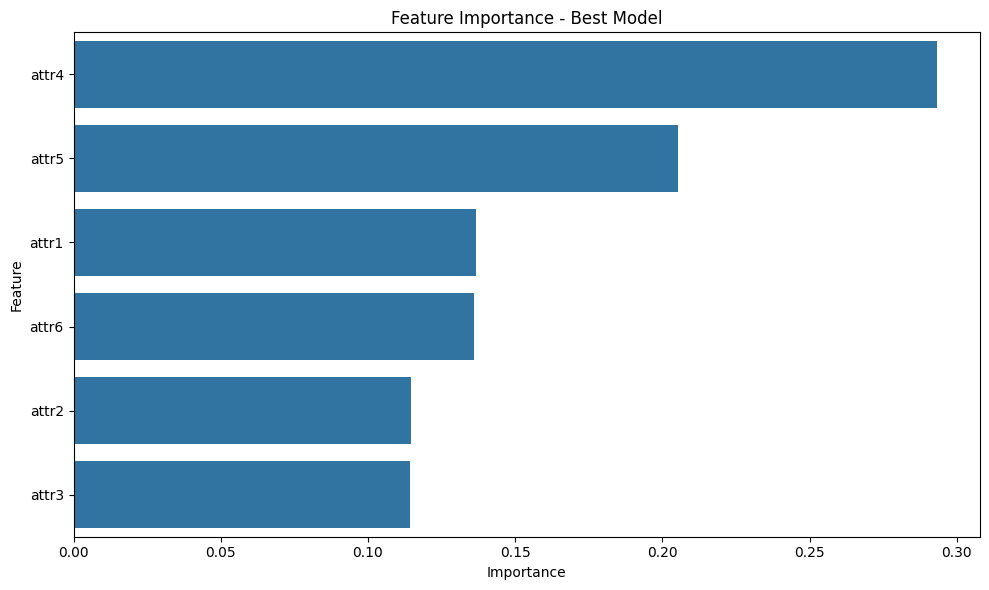

  feature  importance
3   attr4    0.293188
4   attr5    0.205189
0   attr1    0.136775
5   attr6    0.135936
1   attr2    0.114775
2   attr3    0.114138


In [21]:
# Feature Importance
# Get feature importances from the best estimator's classifier
importances = best.named_steps['classifier'].feature_importances_
feature_names = numeric_features

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Feature Importance - Best Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(feature_importance_df)

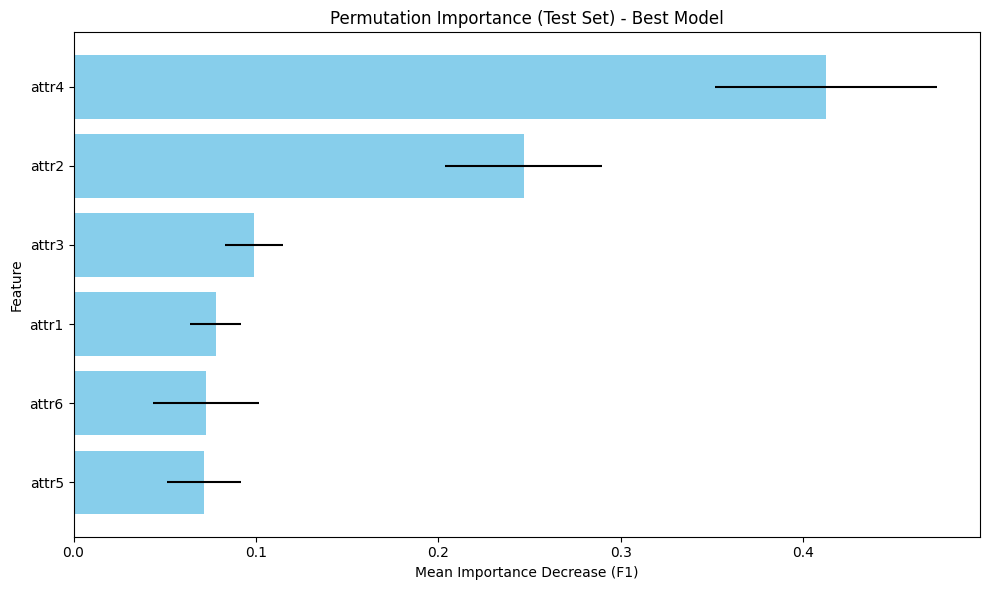

  feature  importance_mean  importance_std
3   attr4         0.412621        0.060693
1   attr2         0.246705        0.042963
2   attr3         0.098907        0.015775
0   attr1         0.078070        0.014006
5   attr6         0.072595        0.028874
4   attr5         0.071601        0.020085


In [22]:
# Compute permutation importance for the best model on the test set
result = permutation_importance(
    best, X_test, y_test, n_repeats=10, random_state=42, scoring='f1'
)

# Create a DataFrame for visualization
perm_importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values('importance_mean', ascending=False)

# Plot permutation importance
plt.figure(figsize=(10, 6))
plt.barh(
    perm_importance_df['feature'],
    perm_importance_df['importance_mean'],
    xerr=perm_importance_df['importance_std'],
    color='skyblue'
)
plt.title('Permutation Importance (Test Set) - Best Model')
plt.xlabel('Mean Importance Decrease (F1)')
plt.ylabel('Feature')
plt.tight_layout()
plt.gca().invert_yaxis()  # To match seaborn's order
plt.show()

print(perm_importance_df)